# 04s — Train the ConditionalUNet surrogate

Trains on random 256×256 tiles of the **train** cities (Istanbul + Orléans),
validates each epoch on full rasters of the **val** city (Rome) and keeps the
checkpoint with the best Rome L1 — so checkpoint selection directly optimises
cross-city generalisation. Cairo (test) is never touched here.

Runs on CUDA / Apple MPS / CPU automatically. Set `WGAST_DATA_ROOT` if the
data lives somewhere else (e.g. an external disk on the training PC).

In [1]:
# --- Configuration -------------------------------------------------------------
import time
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader

from cities import DATA_ROOT
from dataset import WGASTSurrogateDataset
from model_unet import ConditionalUNet
from losses import L1SSIMLoss

MANIFEST = DATA_ROOT / "samples_all" / "manifest.parquet"
CKPT_DIR = DATA_ROOT / "ckpt"

TILE_SIZE  = 256
EPOCHS     = 50
LR         = 1e-3
SSIM_DATA_RANGE = 6.0  # target is z-scored -> ~ ±3σ

device = ("cuda" if torch.cuda.is_available()
          else "mps" if torch.backends.mps.is_available() else "cpu")
BATCH_SIZE  = 8 if device == "cuda" else 2   # the .npz samples are ~80 MB each
NUM_WORKERS = 4 if device == "cuda" else 0

print("device:", device, "| batch:", BATCH_SIZE, "| manifest:", MANIFEST)

device: mps | batch: 2 | manifest: /Users/ihsanbolum/WGAST_w--Prediction/tutorials/data/secondary/samples_all/manifest.parquet


In [2]:
# --- Data ------------------------------------------------------------------------
ds_train = WGASTSurrogateDataset(MANIFEST, tile_size=TILE_SIZE, split="train")
loader = DataLoader(ds_train, batch_size=BATCH_SIZE, shuffle=True,
                    num_workers=NUM_WORKERS, pin_memory=(device == "cuda"))

ds_val = WGASTSurrogateDataset(MANIFEST, split="val")
if len(ds_val) == 0:
    ds_val = None
    print("[WARN] val split (Rome) is empty -- checkpointing on train loss instead")

print(f"train samples: {len(ds_train)}   val samples: {len(ds_val) if ds_val else 0}")

train samples: 76   val samples: 27


In [3]:
# --- Model, loss, optimiser ---------------------------------------------------------
@torch.no_grad()
def val_l1(model, ds):
    """Mean L1 over full val rasters (padded so 4 pool levels divide cleanly)."""
    tot = 0.0
    for i in range(len(ds)):
        s = ds[i]
        sp = s["spatial"].unsqueeze(0).to(device)
        sc = s["scalars"].unsqueeze(0).to(device)
        tg = s["target"].unsqueeze(0).to(device)
        _, _, h, w = sp.shape
        ph, pw = (16 - h % 16) % 16, (16 - w % 16) % 16
        pred = model(F.pad(sp, (0, pw, 0, ph)), sc)[:, :, :h, :w]
        tot += F.l1_loss(pred, tg).item()
    return tot / len(ds)


sample = ds_train[0]
model = ConditionalUNet(in_channels=sample["spatial"].shape[0],
                        scalar_dim=sample["scalars"].shape[0]).to(device)
loss_fn = L1SSIMLoss(ssim_weight=0.1, data_range=SSIM_DATA_RANGE)
opt = torch.optim.AdamW(model.parameters(), lr=LR)
sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=EPOCHS)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"spatial channels: {sample['spatial'].shape[0]}  scalars: {sample['scalars'].shape[0]}")
print(f"trainable params: {n_params:,}")

spatial channels: 91  scalars: 188
trainable params: 8,189,057


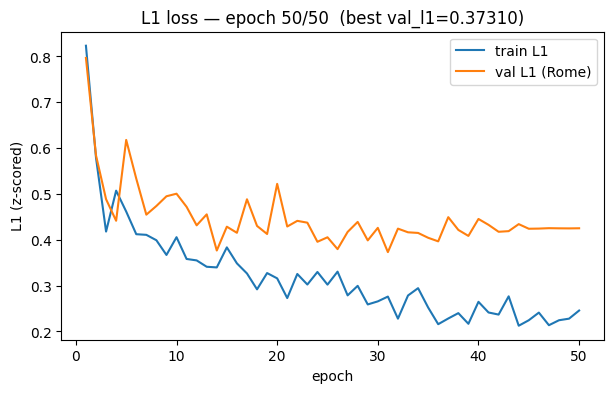

epoch   1  loss=0.90722  l1=0.82341  ssim=0.1619  val_l1=0.79671  (315s)
epoch   2  loss=0.62514  l1=0.57908  ssim=0.5394  val_l1=0.58407  (301s)
epoch   3  loss=0.44748  l1=0.41788  ssim=0.7040  val_l1=0.48848  (292s)
epoch   4  loss=0.54578  l1=0.50715  ssim=0.6137  val_l1=0.44151  (297s)
epoch   5  loss=0.49136  l1=0.46161  ssim=0.7025  val_l1=0.61791  (289s)
epoch   6  loss=0.44091  l1=0.41217  ssim=0.7126  val_l1=0.53341  (286s)
epoch   7  loss=0.43900  l1=0.41078  ssim=0.7178  val_l1=0.45481  (286s)
epoch   8  loss=0.42659  l1=0.39898  ssim=0.7239  val_l1=0.47373  (288s)
epoch   9  loss=0.39356  l1=0.36688  ssim=0.7332  val_l1=0.49492  (290s)
epoch  10  loss=0.43352  l1=0.40562  ssim=0.7210  val_l1=0.50054  (306s)
epoch  11  loss=0.38548  l1=0.35815  ssim=0.7267  val_l1=0.47189  (283s)
epoch  12  loss=0.38197  l1=0.35498  ssim=0.7301  val_l1=0.43155  (277s)
epoch  13  loss=0.36741  l1=0.34110  ssim=0.7369  val_l1=0.45541  (276s)
epoch  14  loss=0.36718  l1=0.33970  ssim=0.7252  v

In [4]:
# --- Train loop -----------------------------------------------------------------------
import matplotlib.pyplot as plt
from IPython.display import clear_output, display

CKPT_DIR.mkdir(parents=True, exist_ok=True)
history = []
log_lines = []
best = float("inf")

fig, ax = plt.subplots(figsize=(7, 4))  # live loss curve, redrawn after each epoch

for epoch in range(1, EPOCHS + 1):
    model.train()
    t_start = time.time()
    tot_loss = tot_l1 = tot_ssim = 0.0
    n = 0
    for batch in loader:
        sp = batch["spatial"].to(device)
        sc = batch["scalars"].to(device)
        tg = batch["target"].to(device)

        pred = model(sp, sc)
        loss, parts = loss_fn(pred, tg)
        opt.zero_grad()
        loss.backward()
        opt.step()

        bs = sp.size(0)
        tot_loss += loss.item() * bs
        tot_l1   += parts["l1"].item() * bs
        tot_ssim += parts["ssim"].item() * bs
        n += bs
    sched.step()

    model.eval()
    v = val_l1(model, ds_val) if ds_val is not None else tot_l1 / n
    history.append(dict(epoch=epoch, loss=tot_loss / n, l1=tot_l1 / n,
                        ssim=tot_ssim / n, val_l1=v))
    log_lines.append(f"epoch {epoch:3d}  loss={tot_loss/n:.5f}  l1={tot_l1/n:.5f}  "
                     f"ssim={tot_ssim/n:.4f}  val_l1={v:.5f}  ({time.time()-t_start:.0f}s)")

    torch.save({"model": model.state_dict()}, CKPT_DIR / "last.pt")
    if v < best:
        best = v
        torch.save({"model": model.state_dict()}, CKPT_DIR / "best.pt")

    # --- live loss curve: watch this and interrupt the kernel once it plateaus ---
    hist = pd.DataFrame(history)
    val_label = "val L1 (Rome)" if ds_val is not None else "train L1 (proxy)"
    ax.clear()
    ax.plot(hist["epoch"], hist["l1"], label="train L1")
    ax.plot(hist["epoch"], hist["val_l1"], label=val_label)
    ax.set_xlabel("epoch"); ax.set_ylabel("L1 (z-scored)")
    ax.set_title(f"L1 loss — epoch {epoch}/{EPOCHS}  (best val_l1={best:.5f})")
    ax.legend()
    clear_output(wait=True)
    display(fig)
    print("\n".join(log_lines))

pd.DataFrame(history).to_csv(CKPT_DIR / "history.csv", index=False)
print(f"\nbest val_l1: {best:.5f}  -> {CKPT_DIR / 'best.pt'}")
plt.close(fig)  

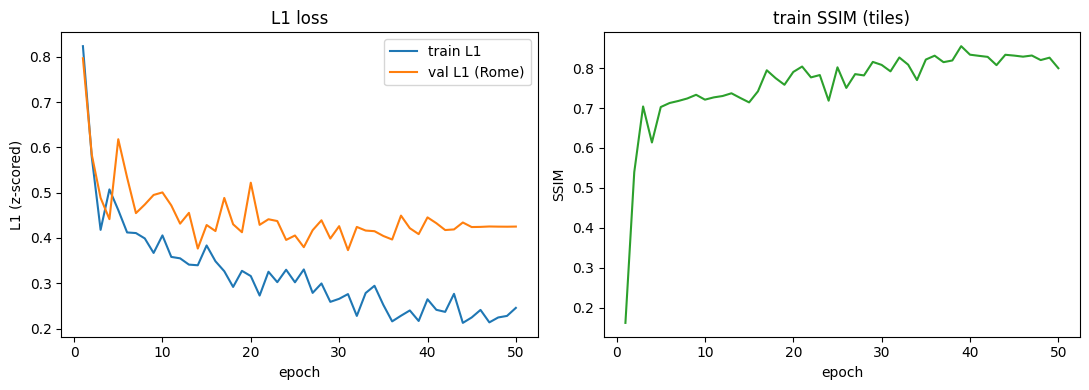

In [5]:
# --- Loss curves -----------------------------------------------------------------------
import matplotlib.pyplot as plt

hist = pd.DataFrame(history) if history else pd.read_csv(CKPT_DIR / "history.csv")

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(hist["epoch"], hist["l1"], label="train L1")
ax[0].plot(hist["epoch"], hist["val_l1"], label="val L1 (Rome)")
ax[0].set_xlabel("epoch"); ax[0].set_ylabel("L1 (z-scored)")
ax[0].set_title("L1 loss"); ax[0].legend()
ax[1].plot(hist["epoch"], hist["ssim"], color="tab:green")
ax[1].set_xlabel("epoch"); ax[1].set_ylabel("SSIM")
ax[1].set_title("train SSIM (tiles)")
plt.tight_layout()
plt.show()